# Laboratorio 13. Redes convolucionales (CNN)

**Pregunta guía:** ¿Cómo aprende una CNN filtros útiles para clasificar imágenes?

## Objetivos
Al finalizar podrás generar imágenes sintéticas; separar train, validación y test; entrenar una CNN; comparar con baseline y visualizar errores.

## Prerrequisitos y conexión
La convolución manual del laboratorio 12 se convierte en capas aprendibles. Se requiere Python básico; cada notebook puede ejecutarse de forma independiente desde un kernel limpio.

## Teoría breve
Una CNN alterna convolución, activación y reducción espacial. Una salida local es $Y_{i,j,k}=\phi(\sum_{u,v,c}K_{u,v,c,k}X_{i+u,j+v,c}+b_k)$. Los filtros comparten parámetros a través de la imagen y aprovechan estructura local.

## Problema y datos
Clasificamos imágenes pequeñas con una línea horizontal o vertical, ruido y semillas fijas. Todos los datos se generan en el notebook: no se requieren descargas ni archivos locales.

## Experimento conceptual
¿Puede una CNN generalizar la orientación de líneas a ejemplos de prueba? Fija la semilla, ejecuta las celdas en orden y cambia una decisión cada vez.

### Preparación del entorno
Importamos NumPy y PyTorch, fijamos semillas y elegimos CPU o GPU de forma opcional.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch import nn
import torch.nn.functional as F

SEED = 2026
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.rcParams['figure.figsize'] = (7, 4)
print('PyTorch:', torch.__version__, '| dispositivo:', device)


PyTorch: 2.8.0+cpu | dispositivo: cpu


**Resultado e interpretación.** La celda confirma el entorno utilizado. El resto del laboratorio está diseñado para CPU; una GPU disponible se utiliza sin ser requisito.


### Crear datos y particiones
Generamos imágenes, etiquetas y splits antes del entrenamiento.


In [2]:
images, labels = [], []
for index in range(500):
    label = index % 2
    image = np.zeros((12, 12), dtype=np.float32)
    if label == 0: image[5:7, 1:11] = 1
    else: image[1:11, 5:7] = 1
    image += np.random.normal(0, 0.18, image.shape).astype(np.float32)
    images.append(np.clip(image, 0, 1)); labels.append(label)
X = torch.tensor(np.array(images)[:, None], device=device)
y = torch.tensor(labels, dtype=torch.long, device=device)
order = torch.randperm(len(y), device=device)
train_idx, val_idx, test_idx = order[:350], order[350:425], order[425:]
print('shapes:', X.shape, '| train/val/test:', len(train_idx), len(val_idx), len(test_idx))
print('baseline test accuracy:', (y[test_idx] == y[train_idx].bincount().argmax()).float().mean().item())


shapes: torch.Size([500, 1, 12, 12]) | train/val/test: 350 75 75
baseline test accuracy: 0.4266666769981384


**Resultado e interpretación.** Los píxeles ya están acotados por la construcción del generador; la partición aleatoria mantiene ejemplos de ambas clases en cada split.


### Entrenar CNN y evaluar
La arquitectura, forward y ciclo de optimización quedan visibles; test se usa al final.


test accuracy: 1.0


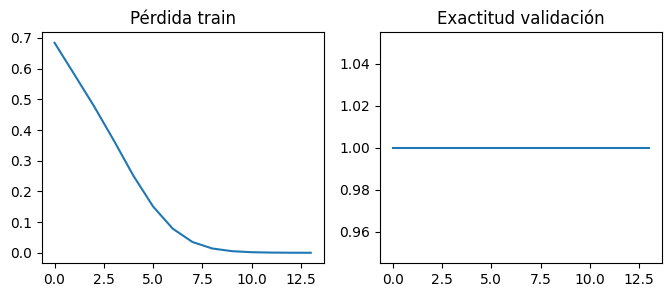

In [3]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                                      nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.classifier = nn.Linear(16 * 3 * 3, 2)
    def forward(self, inputs):
        features = self.features(inputs)
        return self.classifier(features.flatten(1))
model = SmallCNN().to(device); optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
train_losses, val_accuracies = [], []
for epoch in range(14):
    model.train(); logits = model(X[train_idx]); loss = F.cross_entropy(logits, y[train_idx])
    optimizer.zero_grad(); loss.backward(); optimizer.step(); train_losses.append(loss.item())
    model.eval()
    with torch.no_grad(): val_accuracies.append((model(X[val_idx]).argmax(1) == y[val_idx]).float().mean().item())
model.eval()
with torch.no_grad(): test_predictions = model(X[test_idx]).argmax(1)
print('test accuracy:', (test_predictions == y[test_idx]).float().mean().item())
fig, axes = plt.subplots(1, 2, figsize=(8, 3)); axes[0].plot(train_losses); axes[0].set_title('Pérdida train'); axes[1].plot(val_accuracies); axes[1].set_title('Exactitud validación'); plt.show()


**Resultado e interpretación.** Compara test con el baseline y revisa las curvas. Si las clases son perfectamente fáciles, el ejemplo enseña el flujo pero no sustituye evaluación en imágenes reales.


## Limitaciones y conclusiones clave
Los resultados dependen de esta semilla, tamaño de muestra, arquitectura y protocolo. No extrapoles métricas sintéticas a datos reales; separa decisiones de modelado de conclusiones generales. La celda de salida aporta la evidencia numérica y visual para responder la pregunta guía.

- Los parámetros y activaciones determinan cómo se representa la señal.
- La pérdida, el optimizador y el protocolo de evaluación forman parte del experimento.
- Una métrica aislada no describe todos los errores ni garantiza generalización.

## Ejercicios progresivos
1. **Guiado:** Guiado: muestra una imagen mal clasificada y su etiqueta real/predicha.
2. **Independiente:** Independiente: cambia únicamente el tamaño de los filtros y compara validación.
3. **Desafío:** Desafío: modifica rotación y traslación de las imágenes y explica qué sesgo inductivo se conserva.

## Conexión con el siguiente laboratorio
Usa la representación, operación o criterio de evaluación de este laboratorio como punto de partida del siguiente paso de la secuencia.
